In [1]:
import numpy as np
from sklearn.datasets import load_svmlight_file
import matplotlib.pyplot as plt

import sys
import os

ROOT = os.path.abspath("..")
sys.path.append(ROOT)

from src.oracles import *
from src.optimization import *
from src.plot_trajectory_2d import *

In [2]:
DATA_FOLDER = os.path.join(ROOT, "datasets/")

os.makedirs(DATA_FOLDER, exist_ok=True)

In [ ]:
DATASETS = {
    "gisette": "gisette_scale",
    "a9a": "a9a",
    "abalone": "abalone",
    "bodyfat": "bodyfat"
}

In [ ]:
loaded_datasets = {}

for name, file_name in DATASETS.items():
    file_path = os.path.join(DATA_FOLDER, file_name)
    
    print(f"Loading {name} from: {file_path}")
    
    X, y = load_svmlight_file(file_path)
    
    loaded_datasets[name] = (X, y)
    print(f"{name}: X={X.shape}, y={y.shape}")

Loading gisette from: /home/misha/Документы/ITMO/2 курс/opt/ExistanseOfNonExistentSubject/datasets/gisette_scale
gisette: X=(6000, 5000), y=(6000,)
Loading a9a from: /home/misha/Документы/ITMO/2 курс/opt/ExistanseOfNonExistentSubject/datasets/a9a
a9a: X=(32561, 123), y=(32561,)
Loading abalone from: /home/misha/Документы/ITMO/2 курс/opt/ExistanseOfNonExistentSubject/datasets/abalone
abalone: X=(4177, 8), y=(4177,)
Loading bodyfat from: /home/misha/Документы/ITMO/2 курс/opt/ExistanseOfNonExistentSubject/datasets/bodyfat
bodyfat: X=(252, 14), y=(252,)


gisette & a9a

In [10]:
def test(X, y, lams, loss_class, x0, gd_max_iter=100, new_max_iter=10, gd_eps=1e-7, new_eps=1e-7, iter_=''):
    gd_iter_amount = {}
    gd_total_time = {}
    gd_star_norm = {}

    newton_iter_amount = {}
    newton_total_time = {}
    newton_star_norm = {}

    XT = X.T

    matvec_Ax = lambda x: X @ x
    matvec_ATx = lambda x: XT @ x
    if scipy.sparse.issparse(X):
        matmat_ATsA = lambda s: XT @ X.multiply(s[:, None])
    else:
        matmat_ATsA = lambda s: XT @ (s[:, None] * X)

    for lam in lams:

        oracle = loss_class(
            matvec_Ax,
            matvec_ATx,
            matmat_ATsA,
            y,
            regcoef=lam
        )
        
        x_star, message, history = gradient_descent(
            oracle,
            x0,
            trace=True,
            max_iter=gd_max_iter,
            tolerance=gd_eps,
            line_search_options={'method': 'Wolfe'}
        )

        gd_iter_amount[lam] = len(history['func'])
        gd_total_time[lam] = history['time'][-1]
        gd_star_norm[lam] = np.linalg.norm(x_star)

        print(f'GD {lam}, {iter_} is finished')

        x_star, message, history = newton(
            oracle,
            x0,
            trace=True,
            max_iter=new_max_iter,
            tolerance=new_eps,
            line_search_options={'method': 'Wolfe', 'c1':1e-4, 'c2':0.9, 'alpha_0':1.0}
        )

        newton_iter_amount[lam] = len(history['func'])
        newton_total_time[lam] = history['time'][-1]
        newton_star_norm[lam] = np.linalg.norm(x_star)

        print(f'Newton {lam}, {iter_} is finished')

    return (
        gd_iter_amount,
        gd_total_time,
        newton_iter_amount,
        newton_total_time,
        gd_star_norm,
        newton_star_norm
    )

In [ ]:
def test_data_set_stability_all(X_log, y_log, X_exp, y_exp, n_runs=5, gd_max_iter=100, new_max_iter=10, gd_eps=1e-7, new_eps=1e-7):
    dataset_log_name = 'bodyfat'
    dataset_exp_name = 'gisette'
    lams = np.logspace(-5, 5, 11)
    
    gd_iter_runs_log, newton_iter_runs_log = [], []
    gd_time_runs_log, newton_time_runs_log = [], []
    gd_norm_runs_log, newton_norm_runs_log = [], []
    
    gd_iter_runs_exp, newton_iter_runs_exp = [], []
    gd_time_runs_exp, newton_time_runs_exp = [], []
    gd_norm_runs_exp, newton_norm_runs_exp = [], []

    for run in range(n_runs):
        x0 = np.random.normal(0, 1, size=X_log.shape[1])
        
        results_log = test(
            X_log, y_log, lams, LogCoshL2Oracle, x0,
            gd_max_iter, new_max_iter, gd_eps, new_eps, str(run) + '_0'
        )
        gd_iter_log, gd_time_log, newton_iter_log, newton_time_log, gd_norm_log, newton_norm_log = results_log
        gd_iter_runs_log.append([gd_iter_log[lam] for lam in lams])
        newton_iter_runs_log.append([newton_iter_log[lam] for lam in lams])
        gd_time_runs_log.append([gd_time_log[lam] for lam in lams])
        newton_time_runs_log.append([newton_time_log[lam] for lam in lams])
        gd_norm_runs_log.append([gd_norm_log[lam] for lam in lams])
        newton_norm_runs_log.append([newton_norm_log[lam] for lam in lams])
        
        x0 = np.random.normal(0, 1, size=X_exp.shape[1])
        results_exp = test(
            X_exp, y_exp, lams, ExponentialLossL2Oracle, x0,
            gd_max_iter, new_max_iter, gd_eps, new_eps, str(run) + '_1'
        )
        gd_iter_exp, gd_time_exp, newton_iter_exp, newton_time_exp, gd_norm_exp, newton_norm_exp = results_exp
        gd_iter_runs_exp.append([gd_iter_exp[lam] for lam in lams])
        newton_iter_runs_exp.append([newton_iter_exp[lam] for lam in lams])
        gd_time_runs_exp.append([gd_time_exp[lam] for lam in lams])
        newton_time_runs_exp.append([newton_time_exp[lam] for lam in lams])
        gd_norm_runs_exp.append([gd_norm_exp[lam] for lam in lams])
        newton_norm_runs_exp.append([newton_norm_exp[lam] for lam in lams])
    
    gd_iter_runs_log = np.array(gd_iter_runs_log)
    newton_iter_runs_log = np.array(newton_iter_runs_log)
    gd_time_runs_log = np.array(gd_time_runs_log)
    newton_time_runs_log = np.array(newton_time_runs_log)
    gd_norm_runs_log = np.array(gd_norm_runs_log)
    newton_norm_runs_log = np.array(newton_norm_runs_log)
    
    gd_iter_runs_exp = np.array(gd_iter_runs_exp)
    newton_iter_runs_exp = np.array(newton_iter_runs_exp)
    gd_time_runs_exp = np.array(gd_time_runs_exp)
    newton_time_runs_exp = np.array(newton_time_runs_exp)
    gd_norm_runs_exp = np.array(gd_norm_runs_exp)
    newton_norm_runs_exp = np.array(newton_norm_runs_exp)
    
    def plot_stability(metric_name, log_metric, exp_metric, ylabel, method_name, dataset_name=None):
        plt.figure(figsize=(8,5))
        for run in range(n_runs):
            plt.semilogx(lams, log_metric[run], color='blue', alpha=0.4)
            plt.semilogx(lams, exp_metric[run], color='orange', alpha=0.4)
        plt.semilogx(lams, log_metric.mean(axis=0), color='blue', linewidth=2, label='LogCosh Mean')
        plt.semilogx(lams, exp_metric.mean(axis=0), color='orange', linewidth=2, label='Exponential Mean')
        plt.xlabel("λ (regularization)")
        plt.ylabel(ylabel)
        if dataset_name is not None:
            plt.title(f"{method_name} {metric_name} vs Regularization (Stability), {dataset_name}")
        else:
            plt.title(f"{method_name} {metric_name} vs Regularization (Stability)")
        plt.legend()
        plt.grid(True)
        plt.show()
    
    plot_stability("Iterations", gd_iter_runs_log, gd_iter_runs_exp, "Number of iterations", "GD")
    plot_stability("Iterations", newton_iter_runs_log, newton_iter_runs_exp, "Number of iterations", "Newton")

    plot_stability("Runtime", gd_time_runs_log, gd_time_runs_exp, "Time to convergence (seconds)", "GD")
    plot_stability("Runtime", newton_time_runs_log, newton_time_runs_exp, "Time to convergence (seconds)", "Newton")

    plot_stability("Weight Norm Squared", gd_norm_runs_log, gd_norm_runs_exp, r"$||x^*||^2$", "GD", )
    plot_stability("Weight Norm Squared", newton_norm_runs_log, newton_norm_runs_exp, r"$||x^*||^2$", "Newton")

In [18]:
X, y = load_svmlight_file(os.path.join(DATA_FOLDER, DATASETS['gisette']))
X_body, y_body = load_svmlight_file(os.path.join(DATA_FOLDER, DATASETS['bodyfat']))

n_features = X.shape[1]
selected = np.random.choice(n_features, 1000, replace=False)

X_reduced = X[:, selected]

GD 1e-05, 0_0 is finished
Newton 1e-05, 0_0 is finished
GD 0.0001, 0_0 is finished
Newton 0.0001, 0_0 is finished
GD 0.001, 0_0 is finished
Newton 0.001, 0_0 is finished
GD 0.01, 0_0 is finished
Newton 0.01, 0_0 is finished
GD 0.1, 0_0 is finished
Newton 0.1, 0_0 is finished
GD 1.0, 0_0 is finished
Newton 1.0, 0_0 is finished
GD 10.0, 0_0 is finished
Newton 10.0, 0_0 is finished
GD 100.0, 0_0 is finished
Newton 100.0, 0_0 is finished
GD 1000.0, 0_0 is finished
Newton 1000.0, 0_0 is finished
GD 10000.0, 0_0 is finished
Newton 10000.0, 0_0 is finished
GD 100000.0, 0_0 is finished
Newton 100000.0, 0_0 is finished
GD 1e-05, 0_1 is finished
Newton 1e-05, 0_1 is finished
GD 0.0001, 0_1 is finished
Newton 0.0001, 0_1 is finished
GD 0.001, 0_1 is finished
Newton 0.001, 0_1 is finished
GD 0.01, 0_1 is finished
Newton 0.01, 0_1 is finished
GD 0.1, 0_1 is finished
Newton 0.1, 0_1 is finished
GD 1.0, 0_1 is finished
Newton 1.0, 0_1 is finished
GD 10.0, 0_1 is finished
Newton 10.0, 0_1 is finished


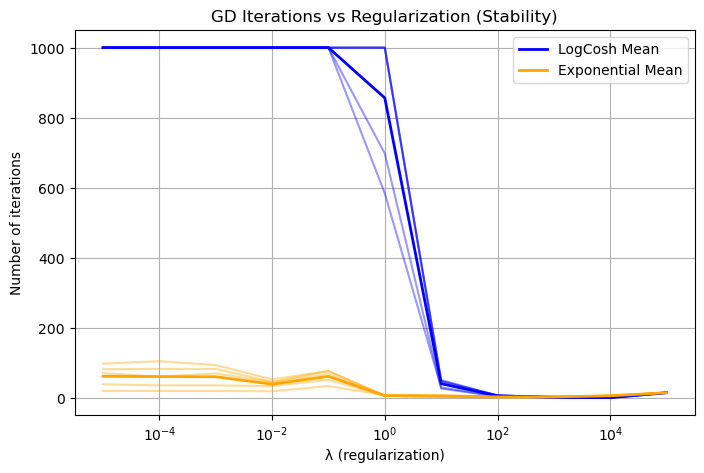

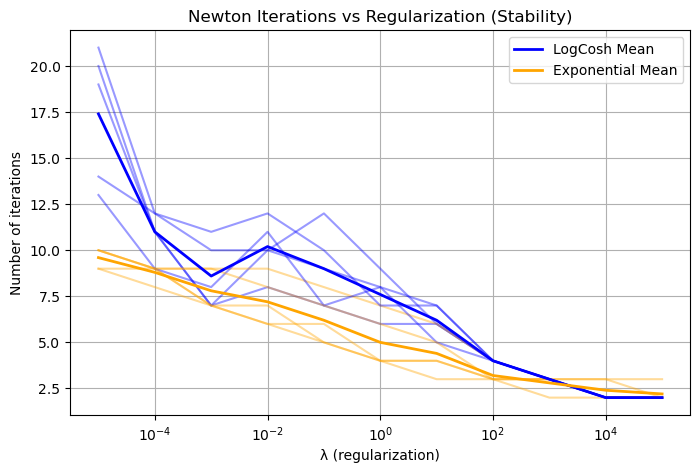

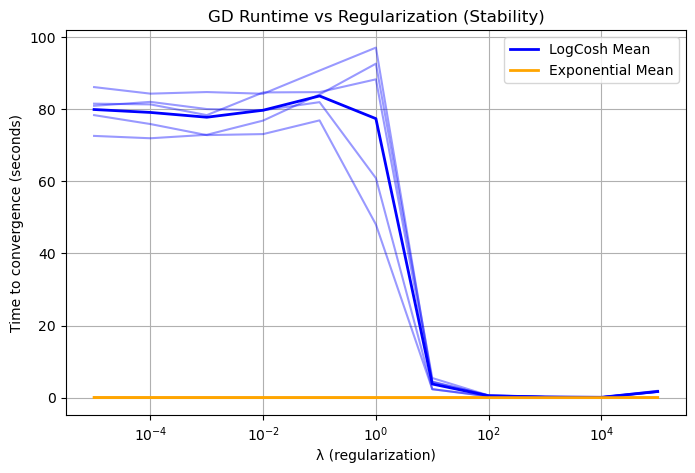

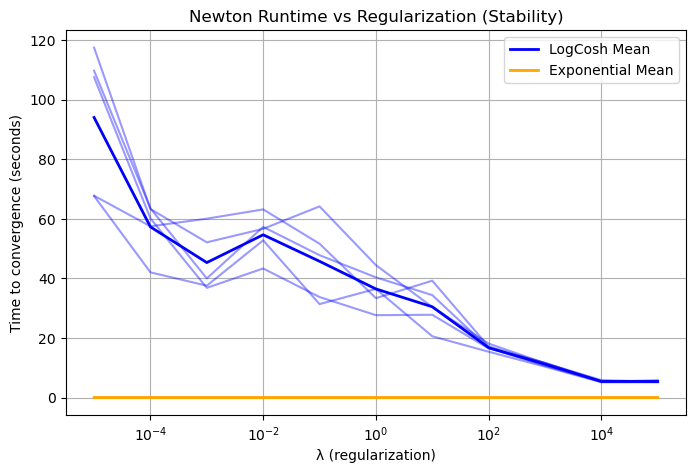

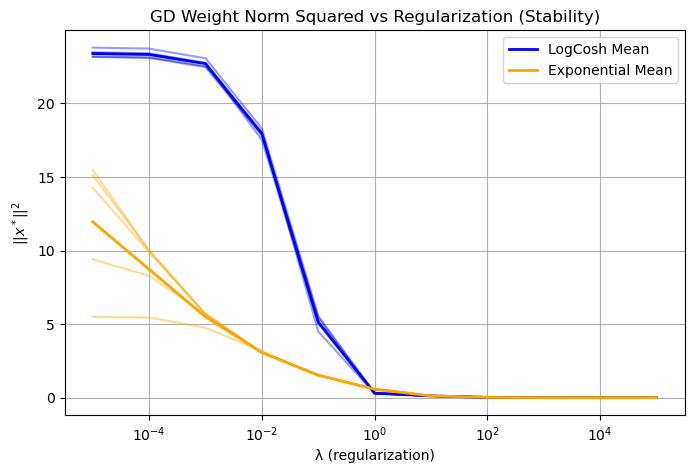

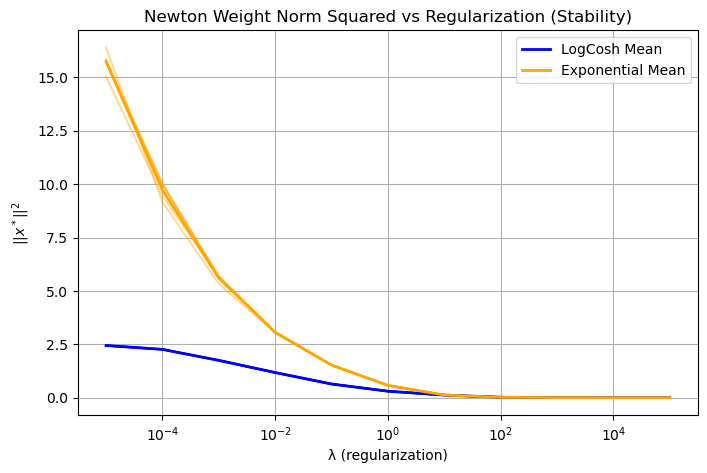

In [19]:

test_data_set_stability_all(X_reduced, y, X_body, y_body, gd_max_iter=1000, new_max_iter=30, gd_eps=1e-8, new_eps=1e-8)